# LeetCode #191: Number of 1 Bits

https://leetcode.com/problems/number-of-1-bits/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (check each bit)** | $O(1)$ — 32 iters | $O(1)$ |
| **Optimal: Brian Kernighan's Algorithm ★** | $O(k)$ where $k$ = popcount | $O(1)$ |

---

## Understanding the Methods

### Brute Force (check each bit)
Check each of the 32 bits with a mask that shifts right on every iteration. Always runs 32 iterations regardless of how many set bits exist.

### Optimal: Brian Kernighan's Algorithm ★
`n & (n-1)` clears the lowest set bit of `n`. Count how many times this operation is needed to reach zero — that count equals the number of set bits. Runs only $k$ iterations where $k$ is the popcount.

**Why this is better than Brute Force:** Skips all zero bits — for sparse integers (few set bits), this is significantly faster in practice. At most 32 iterations but often far fewer.

**Constraints:**
* The input is a 32-bit unsigned integer.

## Solutions

### C#

In [ ]:
public int HammingWeight(int n) {
    int count = 0;
    // Each iteration clears the lowest set bit; count until none remain
    while (n != 0) {
        n &= n - 1;
        count++;
    }
    return count;
}

### Python

In [ ]:
def hammingWeight(self, n: int) -> int:
    count = 0
    # Each iteration clears the lowest set bit; count until none remain
    while n:
        n &= n - 1
        count += 1
    return count

### Go

In [ ]:
func hammingWeight(n int) int {
    count := 0
    // Each iteration clears the lowest set bit; count until none remain
    for n != 0 {
        n &= n - 1
        count++
    }
    return count
}

### Rust

In [ ]:
pub fn hamming_weight(mut n: i32) -> i32 {
    let mut count = 0;
    // Each iteration clears the lowest set bit; count until none remain
    while n != 0 {
        n &= n - 1;
        count += 1;
    }
    count
}

## Example Scenarios

**1. Common Case**
**Input:** n = 11 (binary: 1011)
Iter 1: 1011 & 1010 = 1010 (count=1). Iter 2: 1010 & 1001 = 1000 (count=2). Iter 3: 1000 & 0111 = 0000 (count=3). Result: **3**.

**2. Slightly Complex**
**Input:** n = 128 (binary: 10000000)
Only one set bit. Single iteration: 10000000 & 01111111 = 0 (count=1). Brian Kernighan's runs in 1 iteration vs brute force's 8. Result: **1**.

**3. Edge Case: Time Factor**
**Input:** n = 2147483647 ($2^{31} - 1$, all 31 lower bits set)
Brian Kernighan's runs exactly 31 iterations — worst case for this algorithm. Brute force would also run 32 iterations (checking the sign bit too). Both are $O(1)$ but Kernighan's constant is tighter when bits are sparse.

**4. Edge Case: Space Factor**
**Input:** n = 0
While loop body never executes; count stays 0. No auxiliary data structure allocated. Return **0** — constant $O(1)$ space regardless.

**5. Almost-Impossible but Plausible**
**Input:** n = -1 (all 32 bits set in two's complement, unsigned = $2^{32}-1$)
In languages treating n as signed, `n & (n-1)` still clears the lowest set bit correctly in two's complement. Runs 32 iterations, count = **32**. Demonstrates that Kernighan's works identically for signed representations.

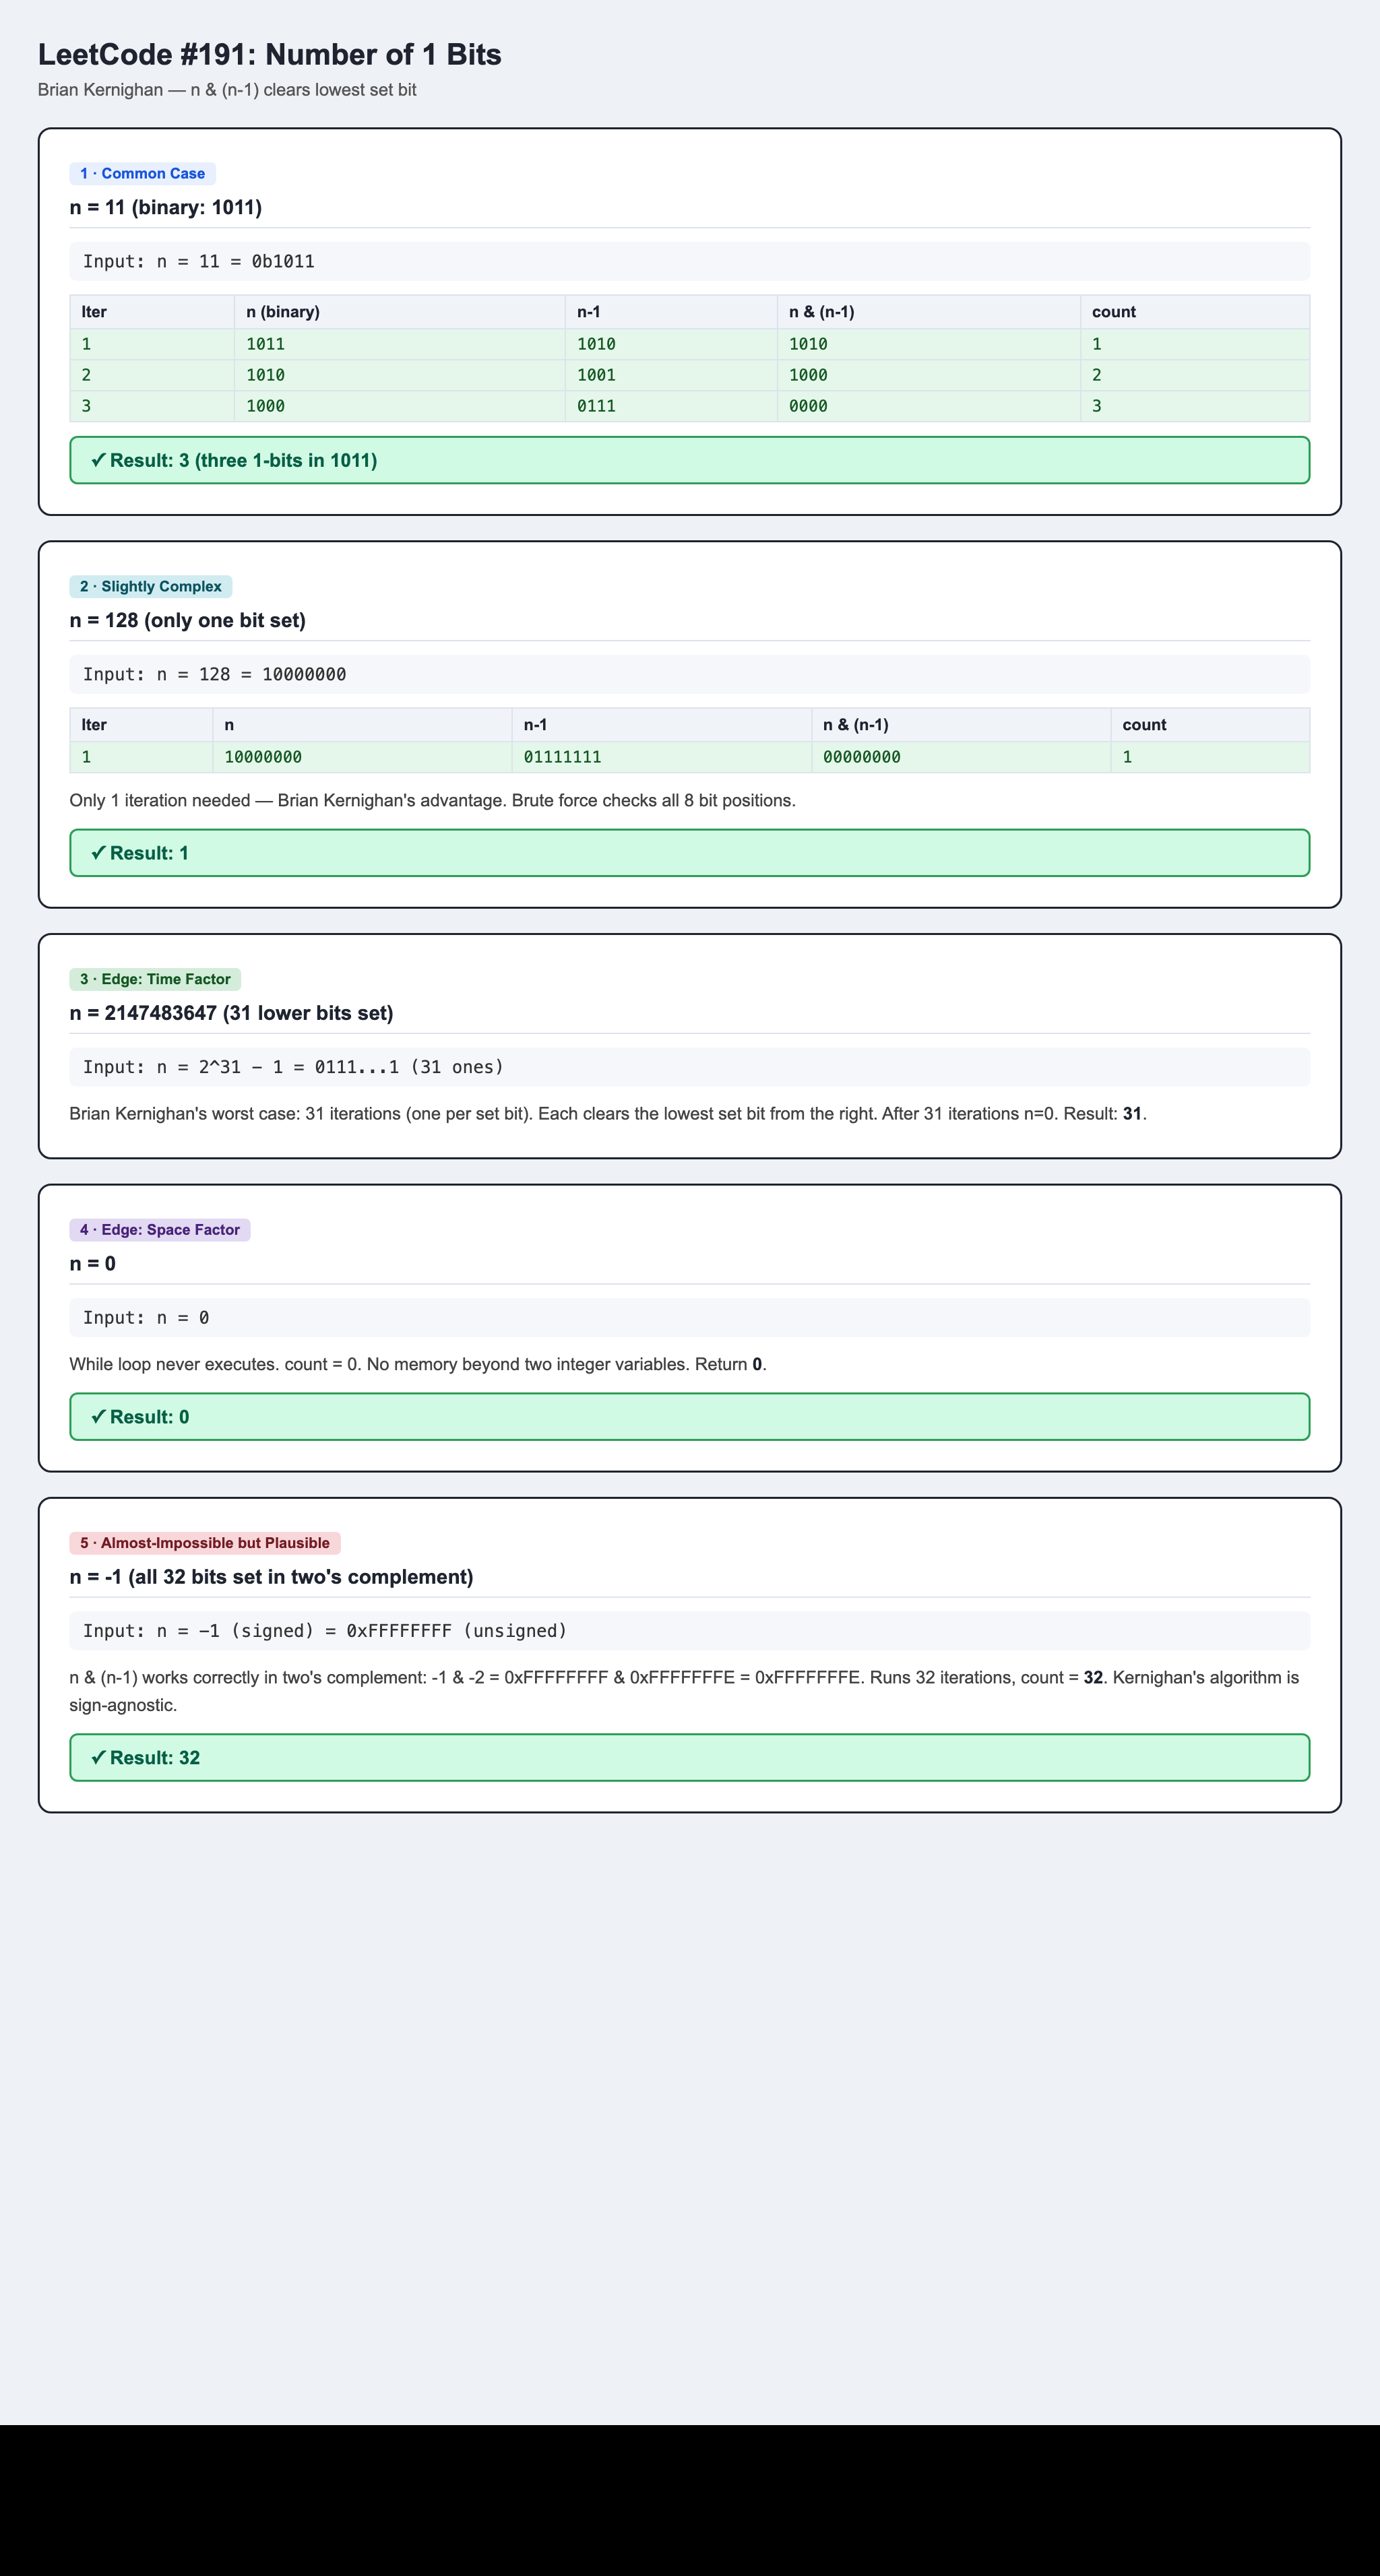